# Lab 2 Text Pre-processing and Regular Expressions

**Course:** ART1501 Natural Language Processing

This notebook solves Task 1 from the lab manual by preprocessing Apple-related Twitter text, extracting hashtags with a regular expression, counting all hashtag occurrences, and identifying the 10 most frequently used hashtags.

## Task 1

Apply text pre-processing and regular expressions to extract and analyze Twitter data regarding Apple company mentions. Determine the total number of hashtags and identify the top 10 most frequently used hashtags in the dataset.

## 1 Import Libraries and Load the Dataset

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

candidate_paths = [
    Path('/kaggle/input/appletwittersentimenttexts/apple-twitter-sentiment-texts.csv'),
    Path('/content/apple-twitter-sentiment-texts.csv'),
    Path('apple-twitter-sentiment-texts.csv')
]
dataset_path = next((path for path in candidate_paths if path.exists()), None)
dataset_url = 'https://raw.githubusercontent.com/lspope/vader_textblob_experiment/main/data/apple-twitter-sentiment-texts.csv'
df = pd.read_csv(dataset_path if dataset_path is not None else dataset_url)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (1630, 2)
Columns: ['text', 'sentiment']


,text,sentiment
0,Wow. Yall needa step it up @Apple RT @heynyla: Music and snapchat at the same damn time. Thank you #Note4,-1
1,What Happened To Apple Inc? http://t.co/FJEXI3oP0U #aapl #apple @MoneyPress http://t.co/wXKmmTMArW,0
2,Thank u @apple I can now compile all of the pics that i communicate with in one place http://t.co/tq1lo09oyA,1
3,The oddly uplifting story of the Apple co-founder who sold his stake for $800 \r\n$AAPL #aapl\r\nhttp://t.co/CiZbVR05PJ,0
4,@apple can i exchange my iphone for a different color lmao i changed my mind,0


## 2 Pre-process the Tweet Text

The text is converted to lowercase, URLs and user mentions are removed, punctuation is removed, and extra spaces are normalized. The `#` symbol is preserved because it is required for hashtag extraction.

In [2]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^\w\s#]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].fillna('').apply(preprocess_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Wow. Yall needa step it up @Apple RT @heynyla: Music and snapchat at the same damn time. Thank you #Note4,wow yall needa step it up rt music and snapchat at the same damn time thank you #note4
1,What Happened To Apple Inc? http://t.co/FJEXI3oP0U #aapl #apple @MoneyPress http://t.co/wXKmmTMArW,what happened to apple inc #aapl #apple
2,Thank u @apple I can now compile all of the pics that i communicate with in one place http://t.co/tq1lo09oyA,thank u i can now compile all of the pics that i communicate with in one place
3,The oddly uplifting story of the Apple co-founder who sold his stake for $800 \r\n$AAPL #aapl\r\nhttp://t.co/CiZbVR05PJ,the oddly uplifting story of the apple co founder who sold his stake for 800 aapl #aapl
4,@apple can i exchange my iphone for a different color lmao i changed my mind,can i exchange my iphone for a different color lmao i changed my mind


## 3 Extract Hashtags with a Regular Expression

The pattern `#\w+` extracts every hashtag beginning with `#` followed by one or more letters, digits, or underscores.

In [3]:
df['hashtags'] = df['clean_text'].str.findall(r'#\w+')
hashtags = df['hashtags'].explode().dropna()
hashtags.head(15).tolist()

['#note4', '#aapl', '#apple', '#aapl', '#aapl', '#aapl', '#iphone6plus', '#aapl', '#apple', '#skyworks', '#swks', '#aapl', '#brcm', '#mu', '#qcom']

## 4 Calculate the Total and Top 10 Hashtags

In [4]:
total_hashtags = len(hashtags)
unique_hashtags = hashtags.nunique()
top_10_hashtags = (
    hashtags.value_counts()
    .rename_axis('Hashtag')
    .reset_index(name='Frequency')
    .sort_values(['Frequency', 'Hashtag'], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)
print(f'Total hashtag occurrences: {total_hashtags}')
print(f'Unique hashtags: {unique_hashtags}')
top_10_hashtags

Total hashtag occurrences: 1616
Unique hashtags: 555


,Hashtag,Frequency
0,#aapl,400
1,#apple,162
2,#iphone,38
3,#december,37
4,#iphone6,29
5,#stocks,15
6,#ipad,14
7,#iphone6plus,13
8,#iphone6s,13
9,#tech,12


## 5 Visualize the Top 10 Hashtags

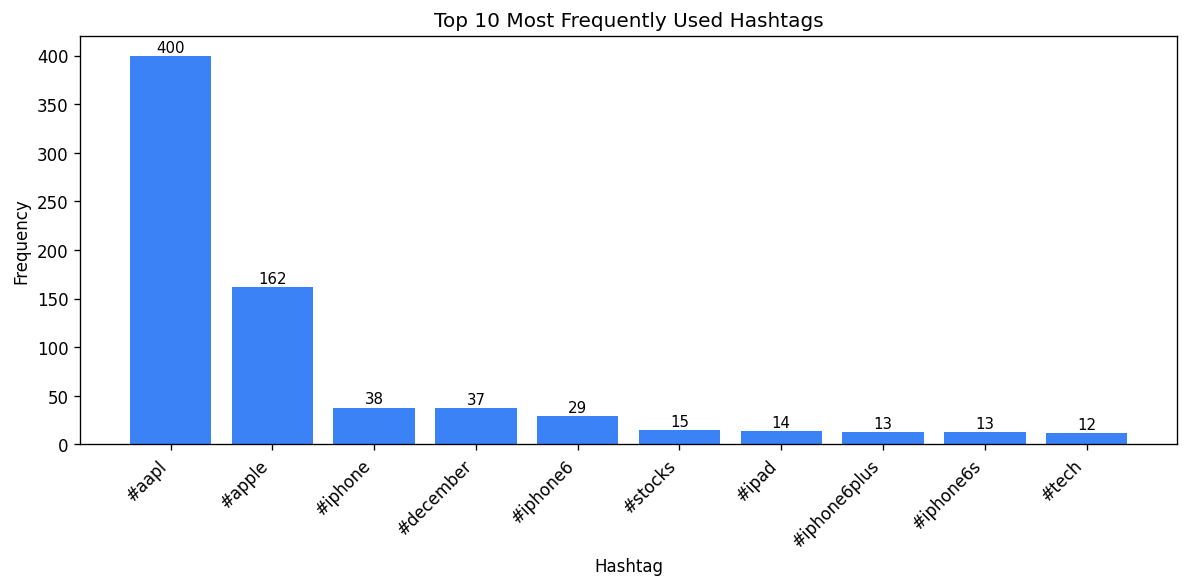

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_hashtags['Hashtag'], top_10_hashtags['Frequency'], color='#3b82f6')
plt.title('Top 10 Most Frequently Used Hashtags')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
for index, value in enumerate(top_10_hashtags['Frequency']):
    plt.text(index, value + 4, str(value), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Final Answer

The dataset contains **1,616 hashtag occurrences**. After converting hashtags to lowercase, there are **555 unique hashtags**.

| Rank | Hashtag | Frequency |
|---:|---|---:|
| 1 | #aapl | 400 |
| 2 | #apple | 162 |
| 3 | #iphone | 38 |
| 4 | #december | 37 |
| 5 | #iphone6 | 29 |
| 6 | #stocks | 15 |
| 7 | #ipad | 14 |
| 8 | #iphone6plus | 13 |
| 9 | #iphone6s | 13 |
| 10 | #tech | 12 |